In [73]:
import numpy as np
import matplotlib.pyplot as plt

# Amplitude modulation example

Carrier wave  $$s_0(t)=A_c cos(2\pi f_c t)$$

Information signal $$m(t)=cos(2\pi f_m t)$$

Modulated wave $$s(t)=A_c \bigg(1+m \> cos(2 \pi f_m t)\bigg)cos(2\pi f_c t)$$

In [74]:
def modulateAM(info_signal, f_c, modulation_index, t = []):
    if len(t) == 0:
        t = np.linspace(0, 1, len(info_signal))
    return (1 + modulation_index * info_signal) * np.cos(2*np.pi*f_c*t)

In [75]:
A_c = 1
f_c = 400    
f_m = 20
modulation_index = 0.5  

In [76]:
t = np.linspace(0, 1, 100000)
carrier = A_c*np.cos(2*np.pi*f_c*t)
info = np.cos(2*np.pi*f_m*t)

am_signal = modulateAM(info, f_c, modulation_index)

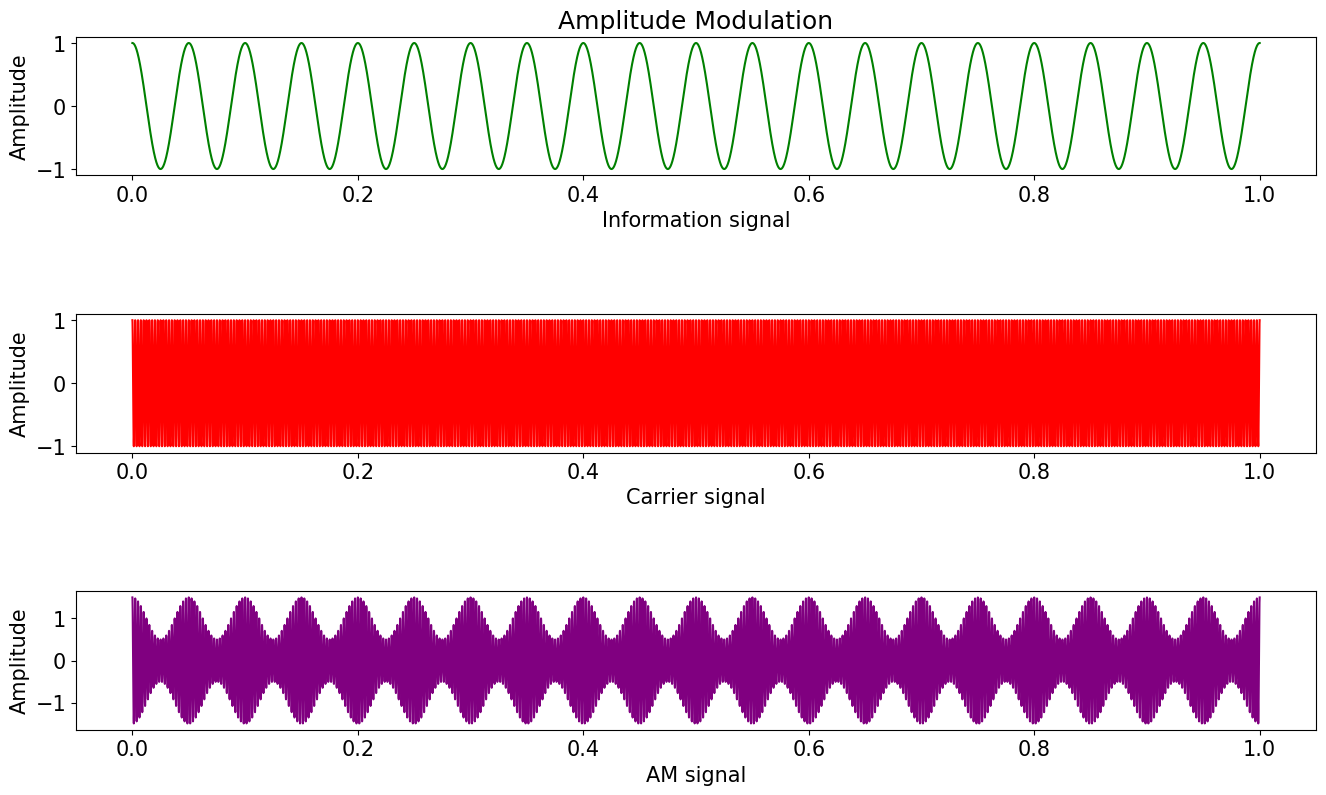

In [85]:
plt.subplot(3,1,1)
plt.title('Amplitude Modulation')
plt.plot(t, info,'g')
plt.ylabel('Amplitude')
plt.xlabel('Information signal')

plt.subplot(3,1,2)
plt.plot(t, carrier, 'r')
plt.ylabel('Amplitude')
plt.xlabel('Carrier signal')

plt.subplot(3,1,3)
plt.plot(t, am_signal, color="purple")
plt.ylabel('Amplitude')
plt.xlabel('AM signal')
plt.subplots_adjust(hspace=1)

plt.rc('font', size=15)
fig = plt.gcf()
fig.set_size_inches(16, 9)
#fig.savefig('Amplitude Modulation.png', dpi=100)

# Encoding sound with AM

In [78]:
import soundfile as sf
import scipy.signal as sg # Comment: Reads audio in floats, writes in non-empty file
import wavio # Comment: Reads audio in integers, writes in a new file

import matplotlib.ticker as ticker

In [79]:
def plotSignalTime(signal):
    plt.plot(signal)
    #plt.stem(signal)
    plt.ylabel('Amplitude')
    plt.xlabel('sample index')
    plt.rc('font', size=15)
    fig = plt.gcf()
    fig.set_size_inches(16, 5)

In [86]:
def plotAmplFreqResp(signal, Fs, use_log_scale = False, use_grid = True):   
    fft_signal = np.fft.fft(signal) # make FFT of info signal
    fft_signal = np.fft.fftshift(fft_signal) # shift FFT so that DC (zero frequency) is at center
    if use_log_scale:
        plt.plot(np.linspace(-Fs/2, Fs/2, len(fft_signal)), 10*np.log10(np.abs(fft_signal)))
        plt.ylabel('Amplitude, dB')
    else:
        plt.plot(np.linspace(-Fs/2, Fs/2, len(fft_signal)), np.abs(fft_signal))
        plt.ylabel('Amplitude')
    plt.xlabel('Frequency, Hz')
    plt.rc('font', size=15)
    
    if use_grid:
        plt.grid(visible=1, which='both')
        plt.minorticks_on()
        plt.grid(which='major',
                linewidth = 2)
        plt.grid(which='minor', 
                linestyle = ':')
    
    fig = plt.gcf()
    fig.set_size_inches(16, 5) 

In [88]:
def plotPhaseFreqResp(fft_signal, Fs, use_grid = True):
    fft_signal = np.fft.fft(fft_signal) # make FFT of info signal
    fft_signal = np.fft.fftshift(fft_signal) # shift FFT so that DC (zero frequency) is at center
    
    plt.plot(np.linspace(-Fs/2, Fs/2, len(fft_signal)), np.angle(fft_signal))
    plt.ylabel('Phase')
    plt.xlabel('Frequency, Hz')
    plt.rc('font', size=15)
    
    if use_grid:
        plt.grid(visible=1, which='both')
        plt.minorticks_on()
        plt.grid(which='major',
                linewidth = 2)
        plt.grid(which='minor', 
                linestyle = ':')
    
    fig = plt.gcf()
    fig.set_size_inches(16, 5)

In [90]:
info_signal_orig

array([0.        , 0.        , 0.        , ..., 0.00085449, 0.00210571,
       0.00689697], shape=(14976,))

In [89]:
# Read audio data from file #

# Reads audio in floats
info_signal_orig, Fs = sf.read('sounds/citation1.wav') # read sound file and sampling frequency

# Reads audio in integers
#wav = wavio.read("sounds/result.wav")
#samples = wav.data
#Fs = wav.rate

print("Number of samples: ", len(info_signal_orig), ", sampling frequency:", Fs)

Number of samples:  14976 , sampling frequency: 16000


In [31]:
# Cut a portion of signal if needed #
do_cut = False

signal_start = 40000 #samples
signal_len = 80000 #samples

if do_cut:
    signal_duration = signal_len / Fs #seconds
    info_signal = info_signal_orig[signal_start:(signal_start+signal_len)] # get "info signal" as part of input signal 
else:
    signal_duration = len(info_signal_orig) / Fs #seconds
    info_signal = info_signal_orig # get "info signal" = input signal 

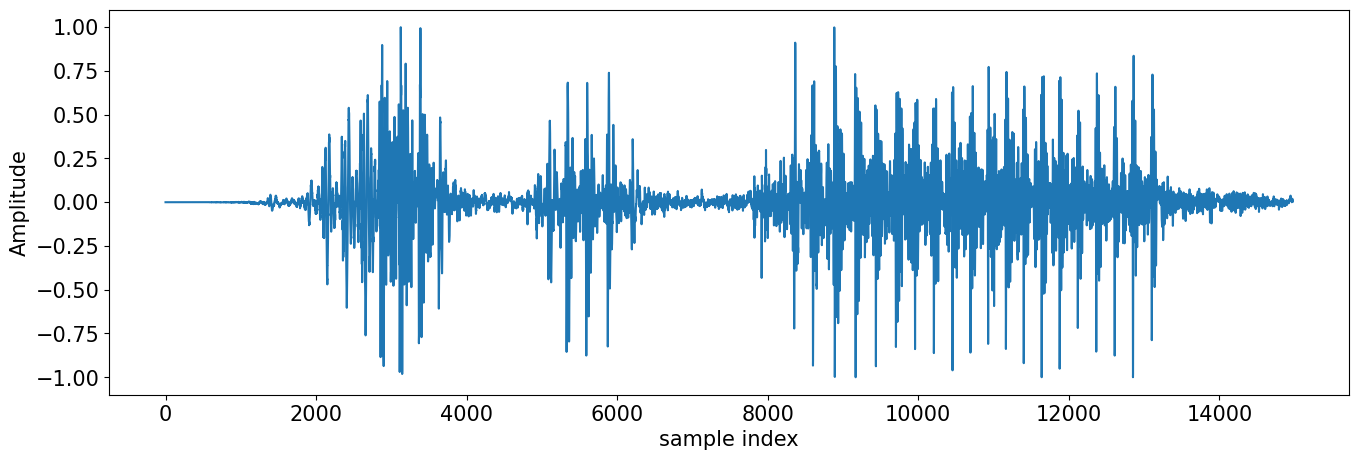

In [32]:
plotSignalTime(info_signal)

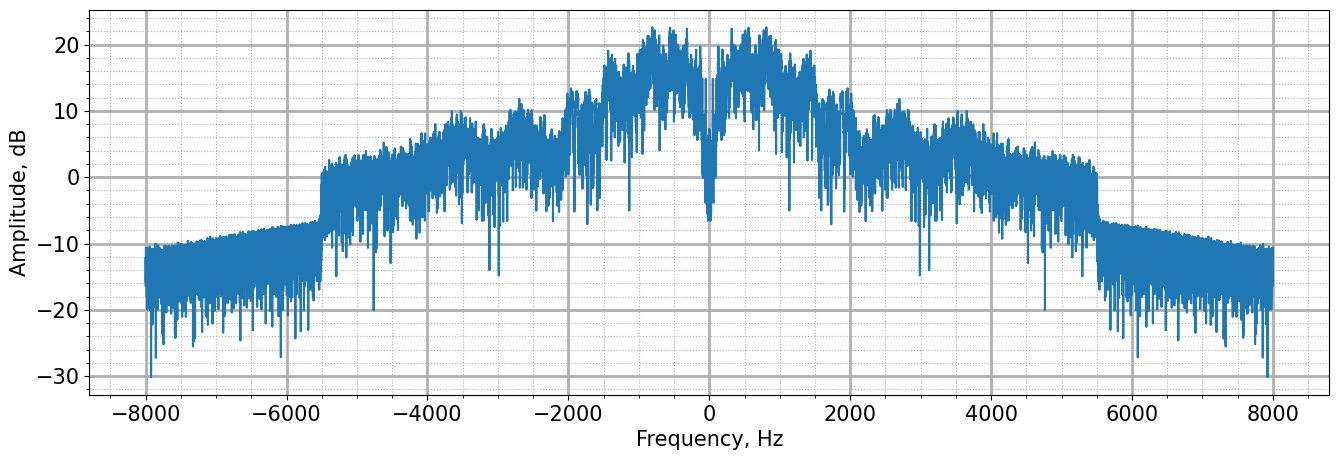

In [35]:
plotAmplFreqResp(info_signal, Fs, True)

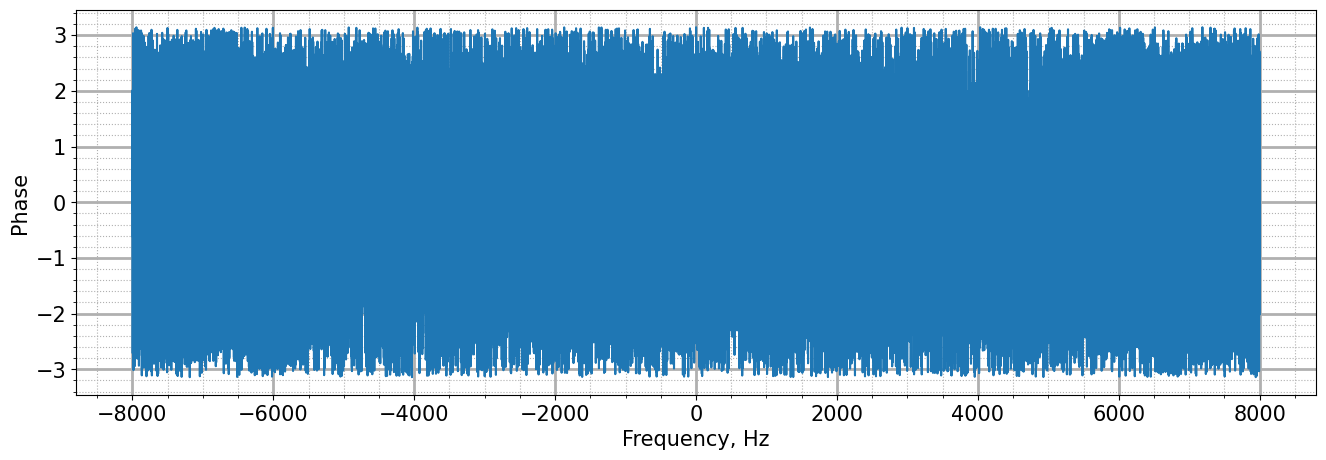

In [36]:
plotPhaseFreqResp(info_signal, Fs, True)

### HW1: What is the acceptable passband for this audio (bandwidth of this signal)? How do you determine it?
Answer: 

In [43]:
# Build a Low Pass Filter before modulation # 

lpf = sg.iirdesign(1500, 2500, 1, 40, fs=Fs) # Select parameters in accordance with HW1 answers
#https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.iirdesign.html

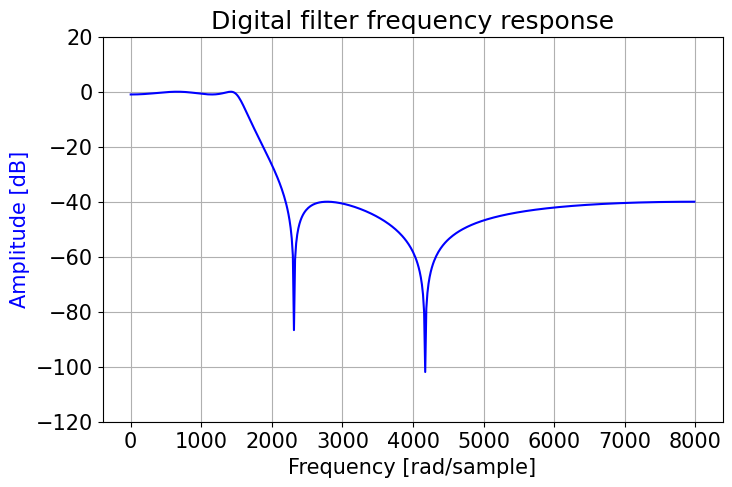

In [46]:
w, h = sg.freqz(*lpf, fs=Fs)

fig, ax1 = plt.subplots()
ax1.set_title('Digital filter frequency response')
ax1.plot(w, 20 * np.log10(abs(h)), 'b')
ax1.set_ylabel('Amplitude [dB]', color='b')
ax1.set_xlabel('Frequency [rad/sample]')
ax1.grid(True)
ax1.set_ylim([-120, 20])
nticks = 8
ax1.yaxis.set_major_locator(ticker.LinearLocator(nticks))
 
fig = plt.gcf()
fig.set_size_inches(8, 5) 

In [47]:
# Apply Low Pass Filter before modulation #

filtered_info_signal = sg.lfilter(*lpf, info_signal)

(-55.0, 5.0)

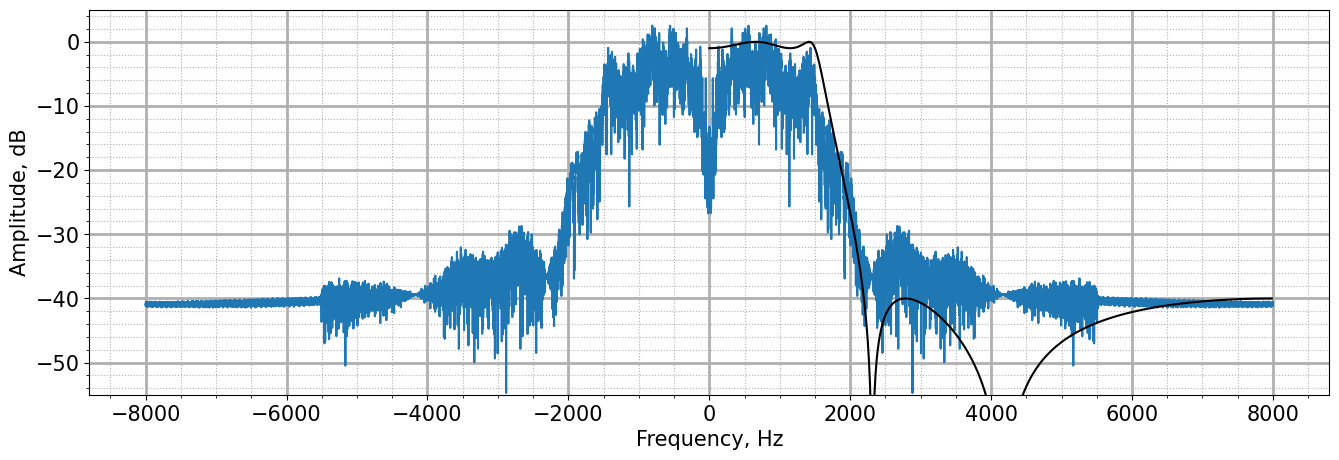

In [48]:
plotAmplFreqResp(filtered_info_signal/100, Fs, True) # For better picture, shifted signal down by 20dB
plt.plot(w, 20 * np.log10(abs(h)), 'k')
plt.ylim((-55,5))

### HW2: Save this signal to an audio file.
Does it sound OK? Maybe too much high-frequency info is lost? Modify filtering parameters to find best parameters.

In [ ]:
# TODO HW2 #

### HW3: Do you always need to filter a modulating signal? Why (not)?
Answer:

In [49]:
# Modulate the carrier frequency (in sound range) with a narrowband information (audio) signal 

f_c = Fs/4 # carrier frequency, Hz
modulation_index = 0.4
t = np.linspace(0, signal_duration, len(filtered_info_signal)) # array of samples timestampes
am_signal = modulateAM(filtered_info_signal, f_c, modulation_index, t)

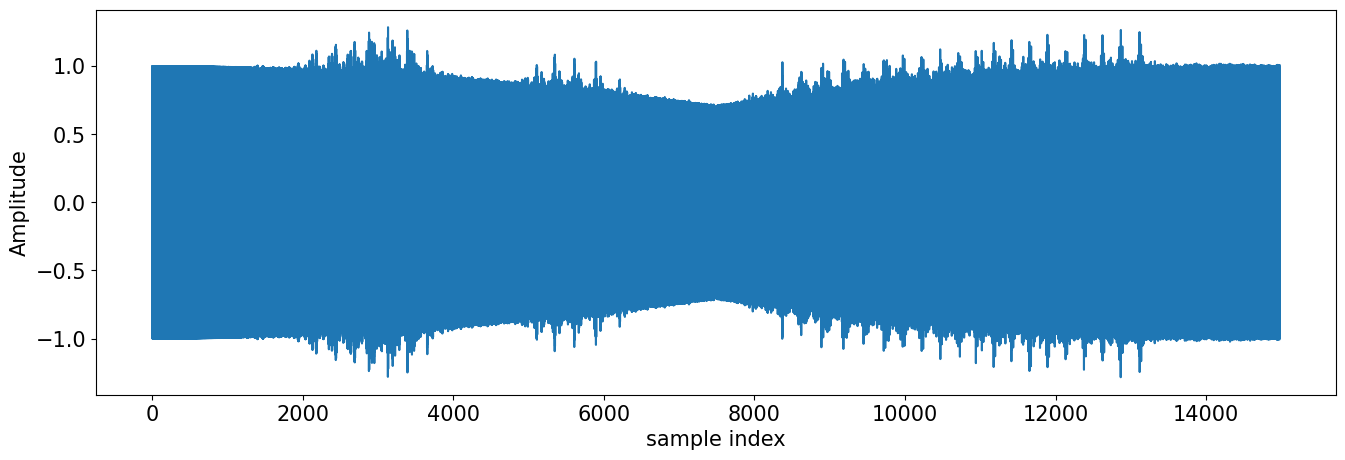

In [50]:
plotSignalTime(am_signal)

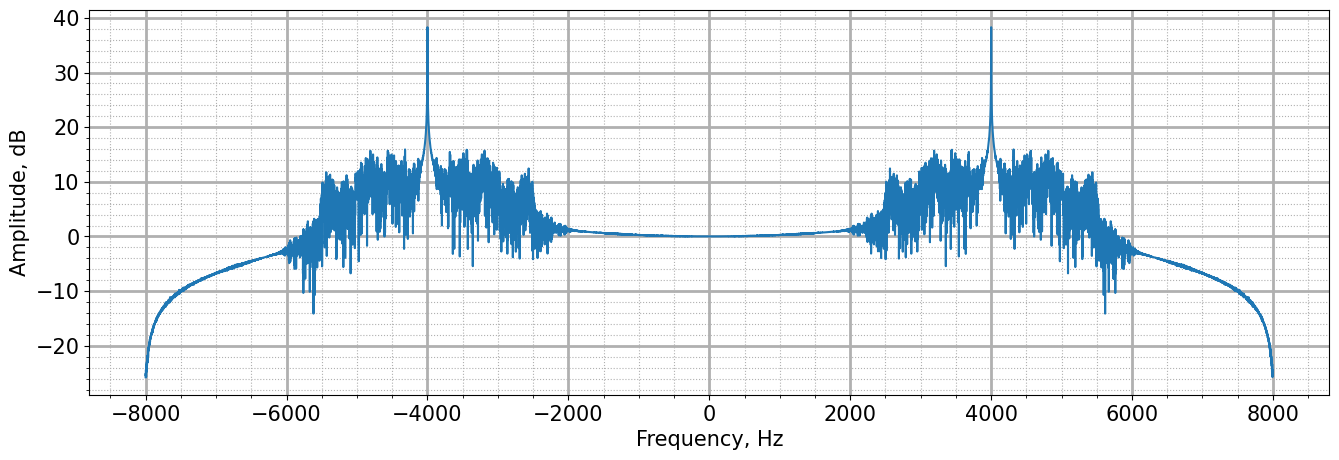

In [51]:
plotAmplFreqResp(am_signal, Fs, True)

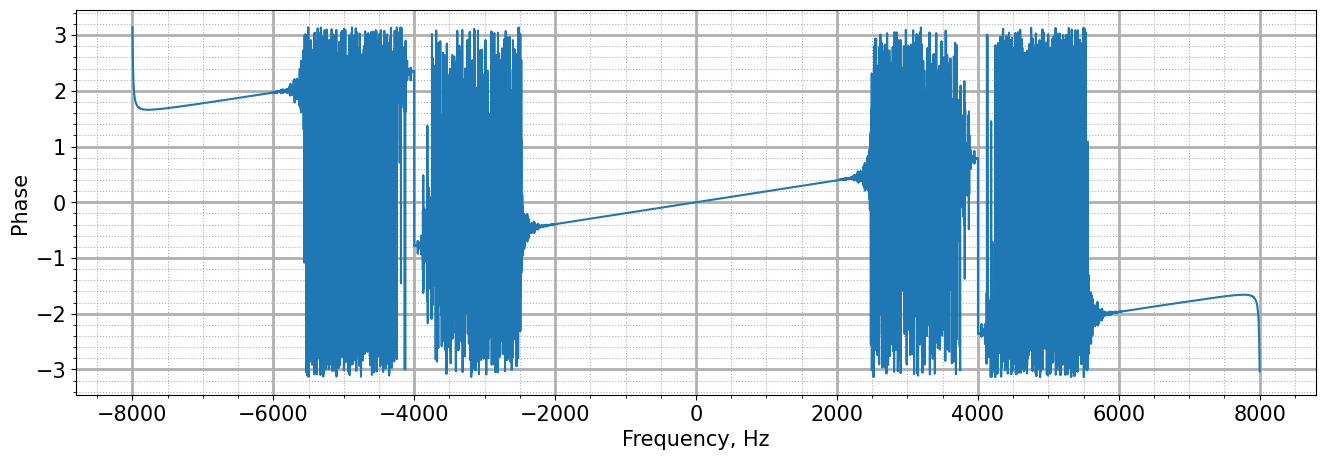

In [27]:
plotPhaseFreqResp(am_signal, Fs, True)

### HW4*: What AM variations can help reducing signal bandwidth?
Answer:

In [28]:
# Write to WAV file
# Warning! Mind your speaker volume before playing audio!!

norm_am_signal = am_signal/max(am_signal) #normalize AM signal, otherwise wavio.write clips it. Warning: this reduces signal power!
wavio.write("sounds/am.wav", norm_am_signal, Fs, sampwidth=2)

# Demodulating AM signal

In [52]:
# Reading AM-modulated signal from file #

am_samples, Fs = sf.read('sounds/am.wav')

# Simulate channel noise #

noise = np.random.normal(0, #mean
                         0.01, #std
                         len(am_samples)) #length
am_signal_recorded = am_samples + noise

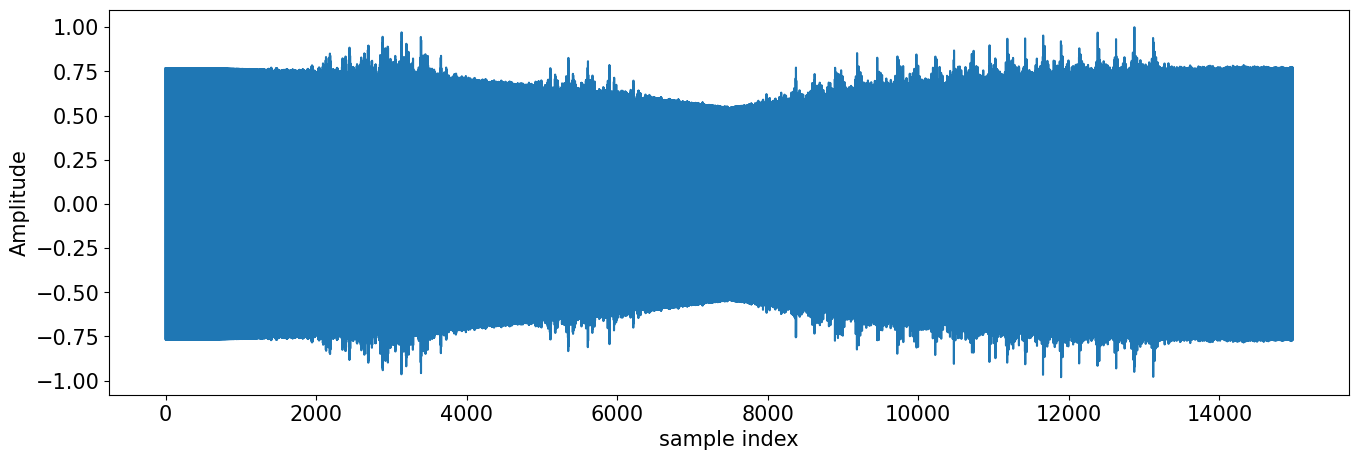

In [19]:
plotSignalTime(am_samples)

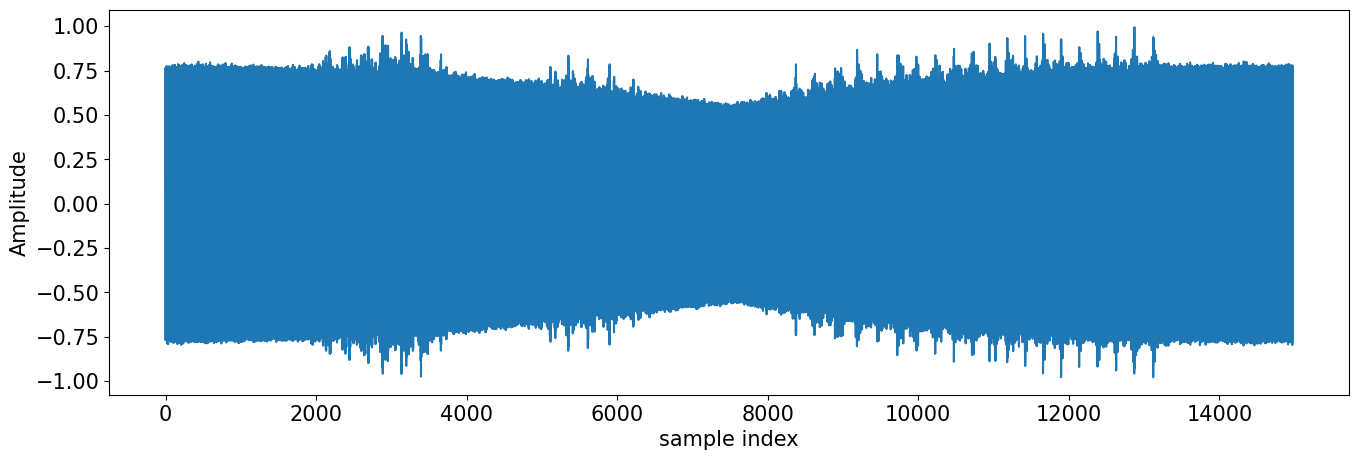

In [20]:
plotSignalTime(am_signal_recorded)

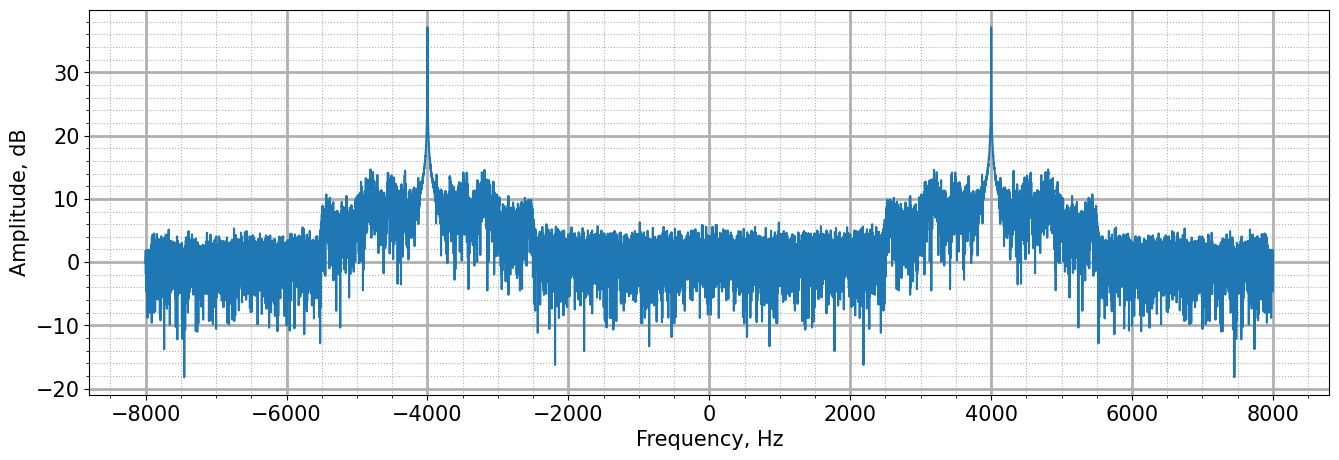

In [53]:
plotAmplFreqResp(am_signal_recorded, Fs, True, True)

In [54]:
# Build a Low Pass Filter to demodulate # 

lpf = sg.iirdesign(1500, 2500, 1, 80, fs=Fs) # Choose correct parameters!

In [55]:
# Demodulate AM - multiply signal by same frequency and filter it #

restored_signal = am_signal_recorded * np.cos(2*np.pi*f_c*t)

filtered_signal = sg.lfilter(*lpf, restored_signal)*2/modulation_index

# Remove DC component, (un)comment optionally
filtered_signal = filtered_signal - np.mean(filtered_signal) 

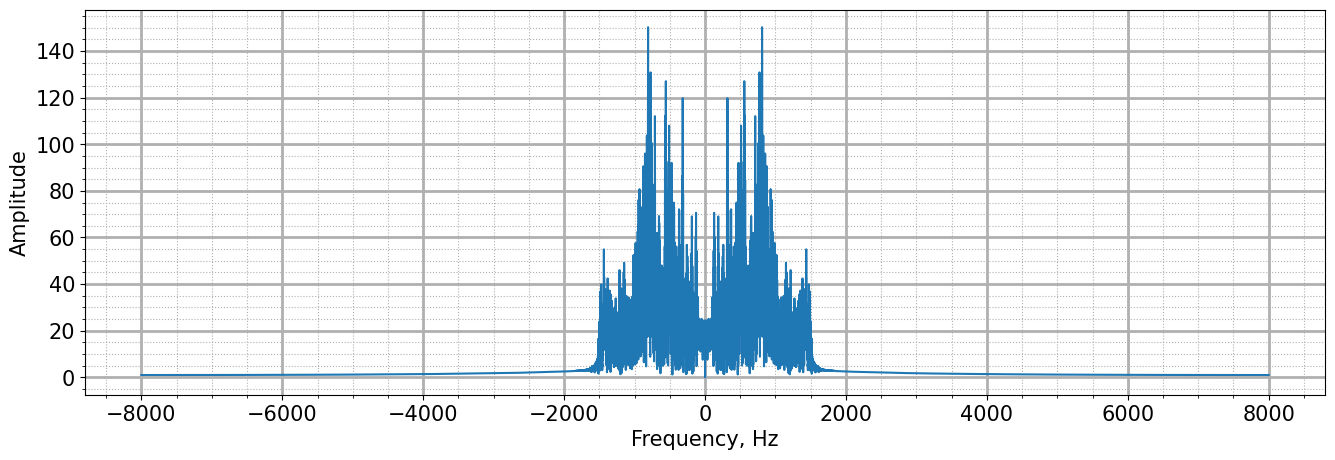

In [59]:
plotAmplFreqResp(restored_signal, Fs, True)
plotAmplFreqResp(filtered_signal, Fs, True)

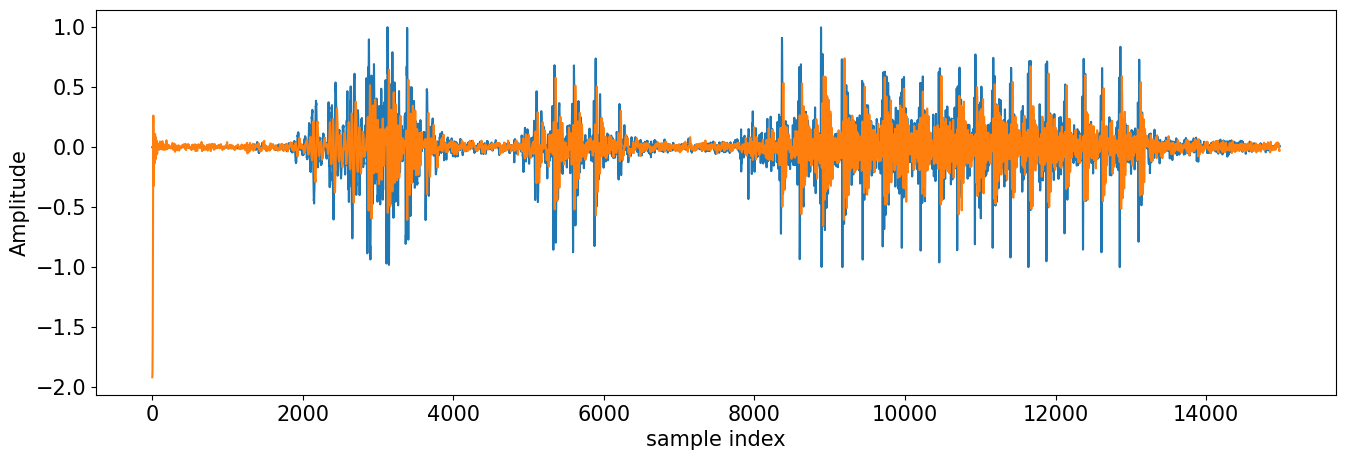

In [60]:
plotSignalTime(info_signal)
plotSignalTime(filtered_signal)

In [37]:
# Write resulting audio to audio file #

norm_filtered_signal = filtered_signal/max(filtered_signal) #normalize signal, otherwise wavio.write clips it
wavio.write("sounds/result1.wav", norm_filtered_signal, Fs, sampwidth=2)

### HW6: Compare the quality of the inital audio and the demodulated recording.
Write a short description of your observations.
### HW7: Inspect how signal responds to strong noise.
Write a short description of your observations.

# Demodulate secret AM signal
### HW8: Demodulate am_secret1 (+1). 
Select the apropriate parameters for correct demodulation. 
Use any python tools needed.
Write a short description of what you saw and how you approached the task.

### HW9*: Demodulate am_secret2 (+1). 
Select the apropriate parameters for correct demodulation. 
Use any python tools needed.
Write a short description of what you saw and how you approached the task.

# MAIN HOMEWORK - Frequency/Phase modulation (+6)